In [ ]:
#@title .
display(HTML("""
<h1 style="text-align:center; font-size:60px;">
🚀 Simulación Monte Carlo
</h1>
"""))

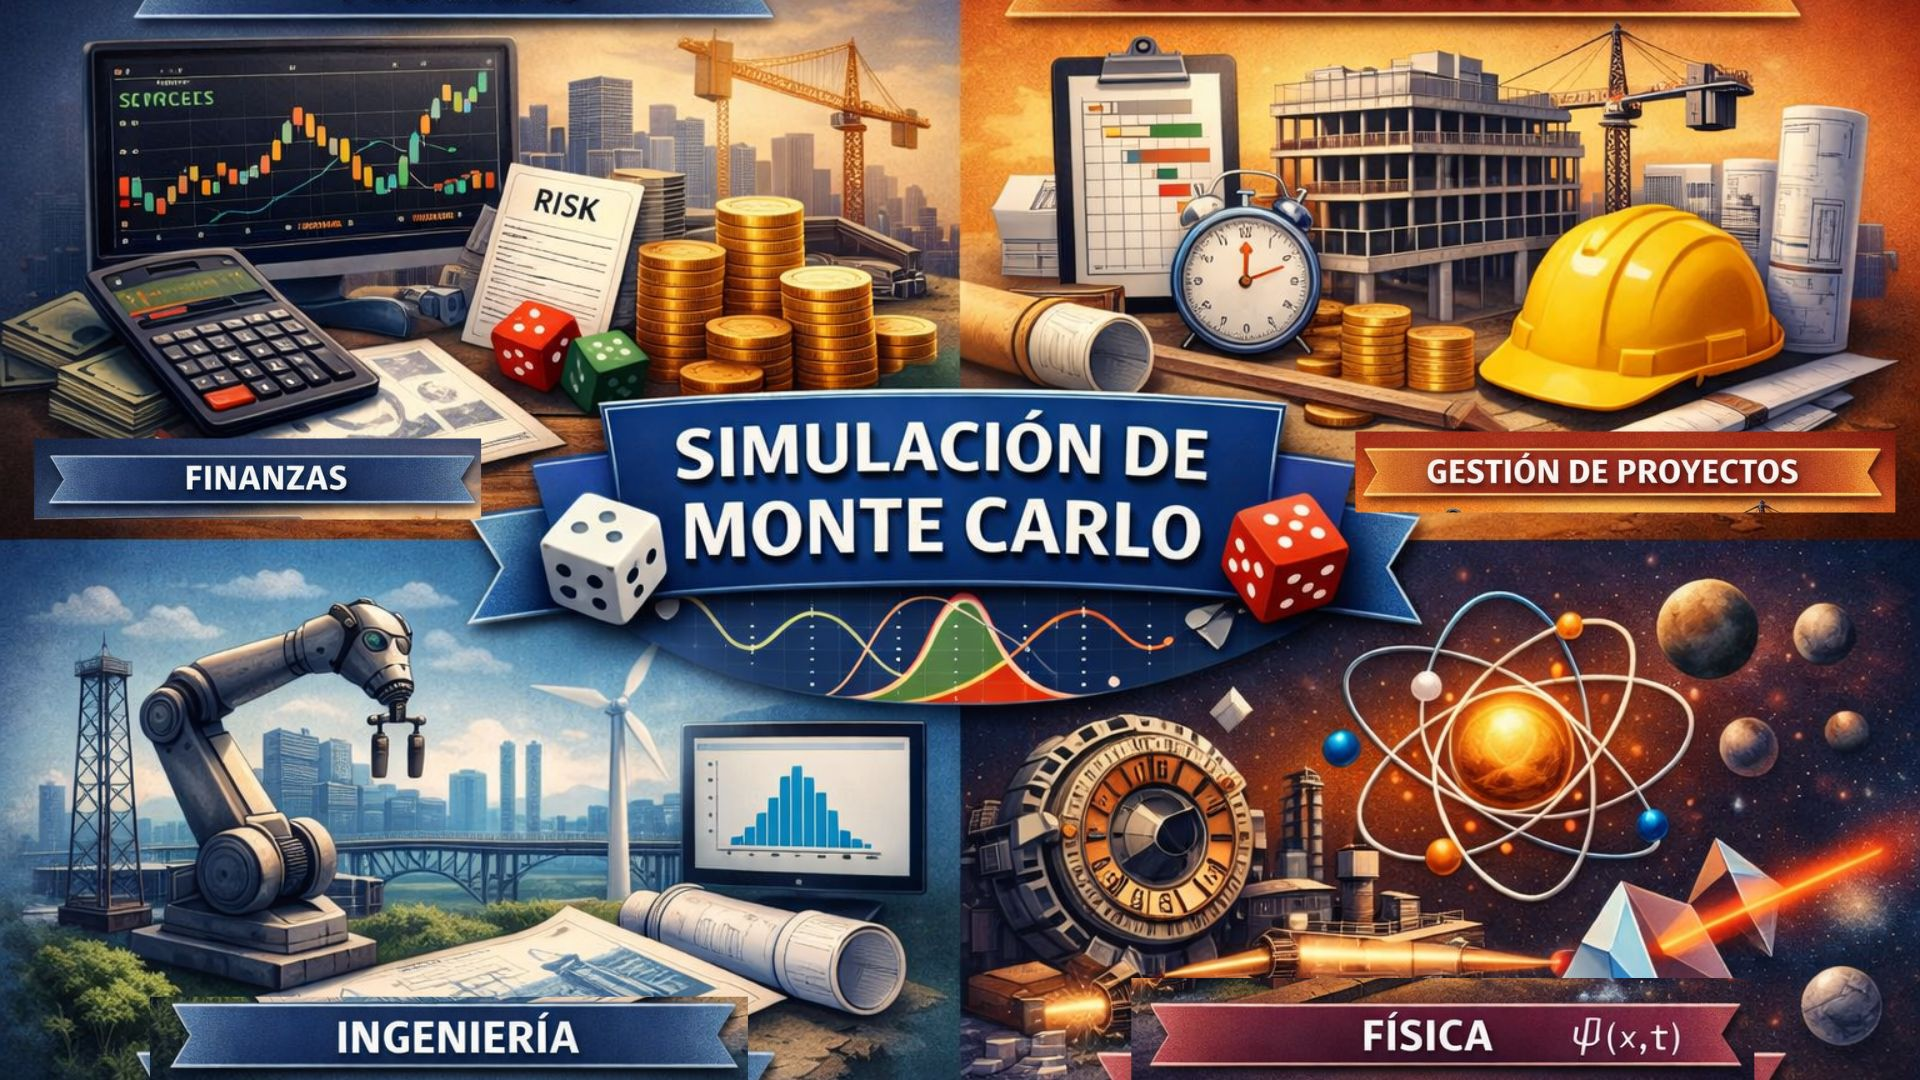

In [ ]:
#@title .
from IPython.display import Image
Image('/content/simulacion Monte.jpg', width=850,)

Características clave de la simulación de Montecarlo:
* Fundamento Probabilístico: Utiliza distribuciones de probabilidad (como la normal o uniforme) para variables de entrada, reflejando la incertidumbre en lugar de usar un único valor fijo.

* Proceso Iterativo: Ejecuta el modelo cientos o miles de veces (iteraciones), generando un nuevo escenario en cada repetición para construir una distribución de resultados posibles.


# Problemas:

## Ejemplo 1

 Hagamos el modelo del tráfico y tiempo de llegada al trabajo, que es un ejemplo de "negocio personal" muy práctico.

En este escenario, el tiempo no es fijo. Depende de:

* Tiempo base sin tráfico

* Clima: (Si llueve, todo se retrasa).

* Semáforos: (Evento aleatorio).

El Problema: ¿Cuánto tardaré en llegar al trabajo?
 aquí tenemos tres variables que "no son fijas" y se mueven en rangos:

* Tiempo de Conducción Base: Entre 20 y 25 minutos (depende de los semáforos en verde).

* Retraso Semaforo : Podrías encontrar un atraso (añade entre 5 y 10 minutos).

* Clima (Lluvia): Si llueve (sucede el 30% de las veces), el retraso extra es de entre 10 y 20 minutos.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definimos el número de simulaciones (10,000 viajes)
n_viajes = 10_000

# 2. Definimos las variables con su incertidumbre
# Tiempo base sin tráfico: entre 20 y 25 minutos
tiempo_base = np.random.uniform(20, 25, n_viajes)

# Retraso por semáforos: entre 5 y 10 minutos
retraso_semaforos = np.random.uniform(5, 10, n_viajes)

# Probabilidad de lluvia (30% de los días)
# Si llueve, suma entre 10 y 20 minutos extra
lluvia = np.random.choice([0, 1], size=n_viajes, p=[0.7, 0.3])
retraso_lluvia = lluvia * np.random.uniform(10, 20, n_viajes)

# 3. Calculamos el tiempo total para cada uno de los 10,000 viajes
tiempo_total = tiempo_base + retraso_semaforos + retraso_lluvia
tiempo_total

array([51.86733561, 26.91145304, 48.25146112, ..., 44.32086197,
       31.22668037, 42.06774784])

In [ ]:
# 4. Analizamos los resultados
media = np.mean(tiempo_total)
prob_tardar_mas_45 = np.mean(tiempo_total > 45) * 100

print(f"Tiempo promedio de llegada: {media:.2f} minutos")
print(f"Probabilidad de tardar más de 45 minutos: {prob_tardar_mas_45:.2f}%")

Tiempo promedio de llegada: 34.61 minutos
Probabilidad de tardar más de 45 minutos: 15.56%


## Vualizacion del Tiempo de Llegada

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

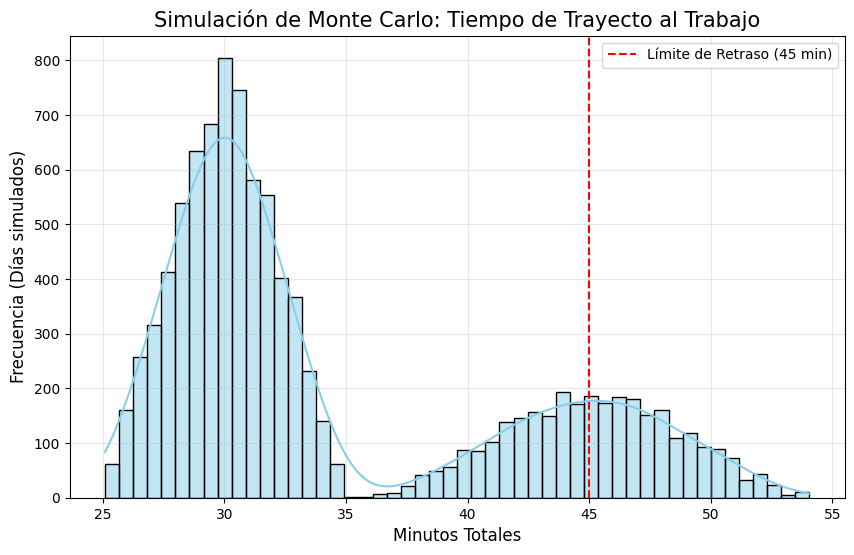

In [ ]:
# 2. Creación del gráfico
plt.figure(figsize=(10, 6))

# Histograma + Curva de Densidad (KDE)
sns.histplot(tiempo_total, kde=True, color="skyblue", bins=50)

# Añadimos una línea para el tiempo límite (ej. 45 min)
plt.axvline(45, color='red', linestyle='--', label='Límite de Retraso (45 min)')

# Configuración estética
plt.title('Simulación de Monte Carlo: Tiempo de Trayecto al Trabajo', fontsize=15)
plt.xlabel('Minutos Totales', fontsize=12)
plt.ylabel('Frecuencia (Días simulados)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Ejemplo 2

Lanzamiento de un nuevo Smartphone
Para calcular la ganancia neta, tienes tres variables que no son fijas:

1. Unidades vendidas: Podrían ser entre 8,000 y 15,000.

2. Precio de venta: Podrías tener que hacer descuentos (entre 500  y 600 dolares).

3. Costo de fabricación: Los componentes suben y bajan (entre 200 y 250 dolares).

¿Cómo lo hace la Simulación de Monte Carlo? la computadora hace lo siguiente 10,000 veces:
1. Elige un número al azar de unidades (ej. 12,450).
2. Elige un precio al azar (ej. $540).

3. Elige un costo al azar (ej. $230).

4. Calcula la ganancia: $12,450 \times (540 - 230) = \$3,859,500$.

In [ ]:
import numpy as np

# Definimos 1,000 simulaciones
n = 10000
np.random.seed(42)
# Variables con incertidumbre (Distribución Uniforme)
ventas = np.random.uniform(8000, 15000, n)
precios = np.random.uniform(500, 600, n)
costos = np.random.uniform(200, 250, n)

# Cálculo de la ganancia para cada uno de los 10,000 escenarios
ganancias = ventas * (precios - costos)

# ¿Cuál es la probabilidad de ganar más de 3 millones?
probabilidad = np.mean(ganancias > 3000000) * 100
print(f"Hay un {probabilidad}% de probabilidad de superar los $3M")

Hay un 80.85% de probabilidad de superar los $3M


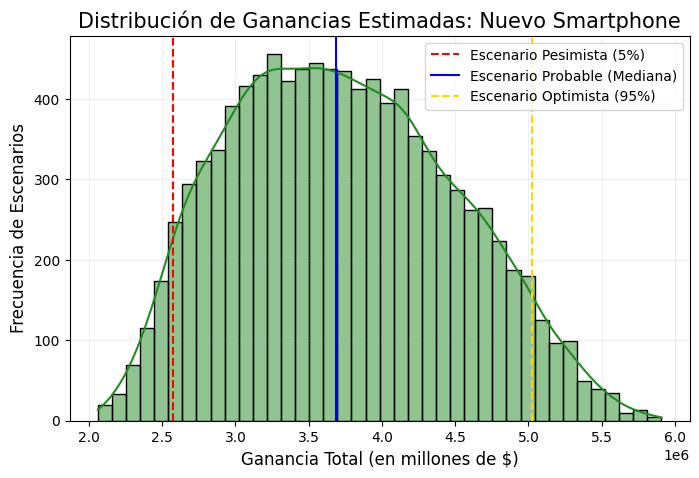

Probabilidad de ganar más de $3,000,000: 80.85%


In [ ]:

# 2. Visualización del Histograma de Probabilidad
plt.figure(figsize=(8, 5))
sns.histplot(ganancias, kde=True, color="forestgreen", bins=40)

# Añadimos líneas para los escenarios clave
plt.axvline(np.percentile(ganancias, 5), color='red', linestyle='--', label='Escenario Pesimista (5%)')
plt.axvline(np.median(ganancias), color='blue', linestyle='-', label='Escenario Probable (Mediana)')
plt.axvline(np.percentile(ganancias, 95), color='gold', linestyle='--', label='Escenario Optimista (95%)')

plt.title('Distribución de Ganancias Estimadas: Nuevo Smartphone', fontsize=15)
plt.xlabel('Ganancia Total (en millones de $)', fontsize=12)
plt.ylabel('Frecuencia de Escenarios', fontsize=12)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# 3. Probabilidad de éxito
prob_exito = np.mean(ganancias > 3000000) * 100
print(f"Probabilidad de ganar más de $3,000,000: {prob_exito:.2f}%")

In [ ]:
np.mean(ganancias > 5_000_000) * 100

np.float64(5.5)

In [ ]:
#@title .
from IPython.display import Video

Video("/content/area_circulo_montecarlo V2.mp4",embed=True)